# Titanic Dataset Analysis

This project analyzes the Titanic dataset to understand factors affecting passenger survival.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The Titanic dataset is loaded and inspected to understand its structure and available features.

In [2]:
tit = pd.read_csv('Titanic-Dataset.csv')


## Initial Exploration

In this section, basic information such as dataset shape, column names, and summary statistics are examined.

In [3]:
print(tit.shape)
tit.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
tit.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
tit.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
tit.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
tit.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## Missing Value Analysis

Before analysis, missing values are identified and handled appropriately.

In [8]:
tit.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

Missing values in the Age column are replaced using the mean value. Other columns are checked to ensure data consistency.

In [9]:
tit['Age'] = tit['Age'].fillna(tit['Age'].mean())
tit['Cabin'] =tit['Cabin'].bfill()

In [10]:
tit.dropna(inplace = True)

In [11]:
tit.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [12]:
tit.duplicated().sum()

np.int64(0)

In [13]:
print("The Shape Of Dataset after dropping duplicate is ", tit.shape)

The Shape Of Dataset after dropping duplicate is  (888, 12)


## Survival Analysis by Gender

This analysis examines whether passenger gender affected survival probability.

Sex
female    0.740385
male      0.189236
Name: Survived, dtype: float64


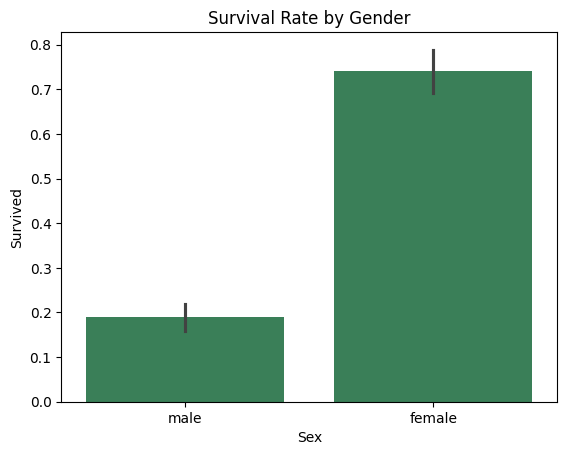

In [14]:
survival_gender = tit.groupby('Sex')['Survived'].mean()
print(survival_gender)

sns.barplot(x='Sex', y='Survived', data=tit, color="seagreen")
plt.title('Survival Rate by Gender')
plt.show()

#### Conclusion:
Female passengers had a significantly higher survival rate than male passengers.

## Survival Analysis by Passenger Class

Passenger class may have influenced access to safety measures during the disaster.

Pclass
1    0.626168
2    0.472826
3    0.242857
Name: Survived, dtype: float64


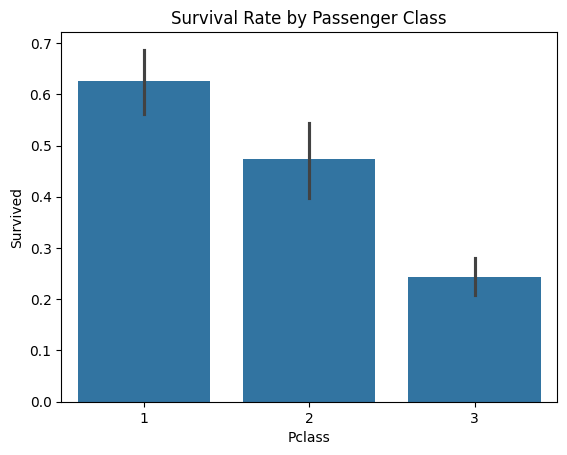

In [15]:
survival_class = tit.groupby('Pclass')['Survived'].mean()
print(survival_class)

sns.barplot(x='Pclass', y='Survived', data=tit)
plt.title('Survival Rate by Passenger Class')
plt.show()

#### Conclusion:
First-class passengers had the highest survival rate.
Third-class passengers had the lowest survival rate.

## Age Distribution

The age distribution of passengers is visualized to understand the demographic composition of the dataset.

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353933
Adult          0.396907
Senior         0.190476
Name: Survived, dtype: float64


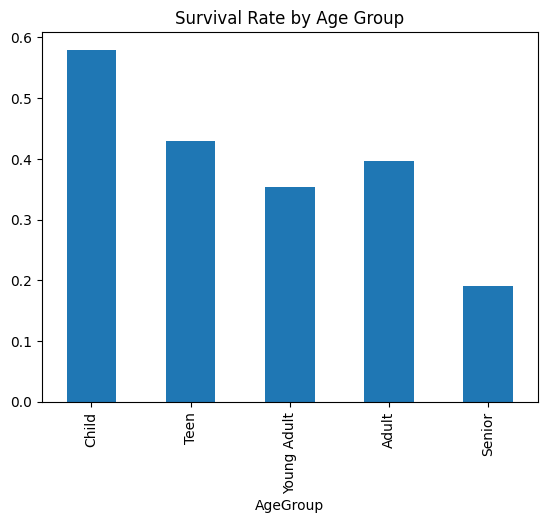

In [16]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

tit['AgeGroup'] = pd.cut(tit['Age'], bins=bins, labels=labels)

age_survival = tit.groupby('AgeGroup')['Survived'].mean()

print(age_survival)

age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.show()

#### Conclusion:
Survival rates varied across age groups, with younger passengers generally showing better survival chances.

## Age Histogram

A histogram is used to visualize the distribution of passenger ages and identify the most common age ranges.

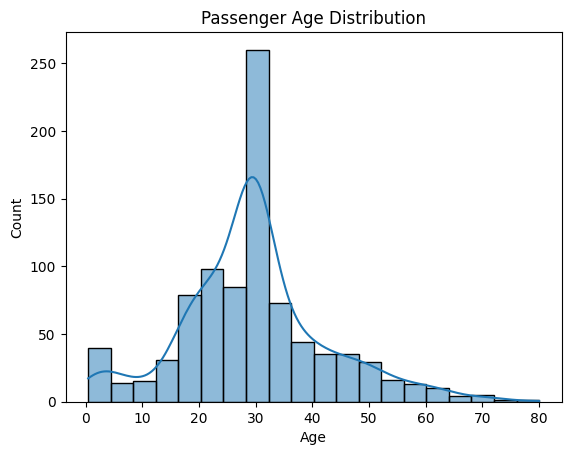

In [17]:
sns.histplot(tit['Age'], bins=20, kde=True)
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Passenger Class Distribution

This visualization shows how passengers were distributed among different ticket classes.

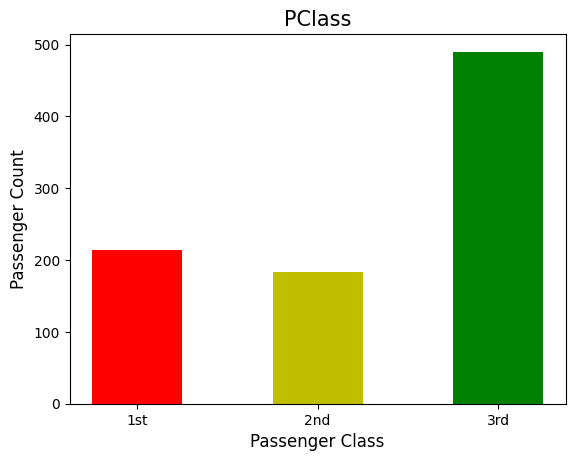

In [18]:
Pc_count = tit['Pclass'].value_counts()
x = ["1st" , "2nd" , "3rd"]
y = [Pc_count[1] , Pc_count[2] , Pc_count[3]]
c = ["r" , "y" , "g"]

plt.xlabel("Passenger Class", fontsize = 12)
plt.ylabel("Passenger Count" , fontsize =12)
plt.title("PClass" , fontsize =15)
plt.bar(x,y, color =c , width =0.5)
plt.show()

#### Observation

The majority of passengers belonged to third class, followed by first and second class passengers.

## Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables.

In [19]:
correlation = tit.select_dtypes(include=['number']).corr()

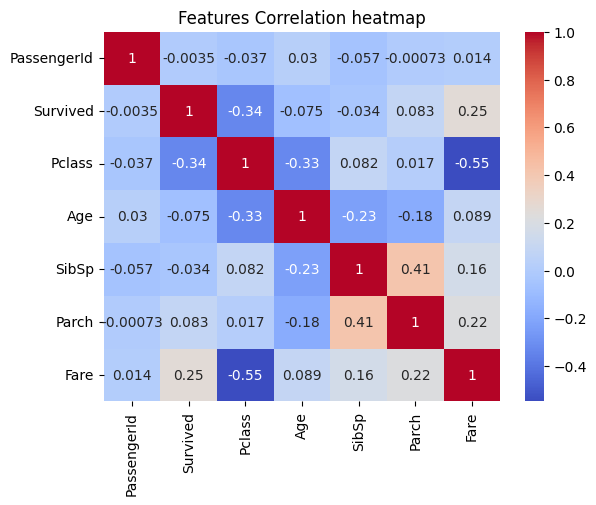

In [20]:
sns.heatmap(correlation , annot = True , cmap = 'coolwarm')
plt.title("Features Correlation heatmap")
plt.show()

#### Observation

The heatmap highlights relationships among numerical features and helps identify variables that may influence survival.

## Key Findings

1. Female passengers had a higher survival rate than male passengers.
2. First-class passengers were more likely to survive.
3. Passenger age showed variation in survival patterns.
4. Data visualization helped identify important relationships among features.

## Conclusion

The analysis indicates that gender and passenger class had a strong influence on survival outcomes. Female passengers and first-class passengers experienced higher survival rates. Data visualization helped identify important patterns within the dataset.